In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
data = pd.read_csv("My_Uber_Drives_2016.csv")

In [3]:
data

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [4]:
data["START_DATE*"].dtype

dtype('O')

In [10]:
pd.date_range(start="2025-01-01",end="2025-12-31",freq="D")

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10',
               ...
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', length=365, freq='D')

In [11]:
month_date_map = {
    1:31,
    2:28,
    3:31,
    4:30,
    5:31,
    6:30,
    7:31,
    8:31,
    9:30,
    10:31,
    11:30,
    12:31
}

In [17]:
dates = []
for i in range(1,13,1):
    if i < 10:
        date = f"2025-0{i}-"
    else:
        date = f"2025-{i}-"
    for j in range(1,month_date_map[i]+1,1):
        if j < 10:
            date += f"0{j}"
        else:
            date += f"{j}"
        dates.append(date)
        if i < 10:
            date = f"2025-0{i}-"
        else:
            date = f"2025-{i}-"

In [47]:
def get_datetime_range(start_date, end_date, format_="%Y-%m-%d",freq = "D"):
    if format_ == "%Y-%m-%d":
        if (len(start_date) == 10 and start_date[4] == "-" and start_date[7] == "-"):
            try: 
                start_yyyy = int(start_date[:4])
                start_mm = int(start_date[5:7])
                start_dd = int(start_date[8:])
                if not (start_yyyy > 1900 and 1 <= start_mm <= 12):
                    print("start_date : Invalid start_date year and month")
                    return
                else:
                    if not (1 <= start_dd <= month_date_map[start_mm]):
                        print("start_date : Invalid start date")
                        return
                    
            except Exception as e:
                print("start_date : Invalid Start_date",e)
                return
        if (len(end_date) == 10 and end_date[4] == "-" and end_date[7] == "-"):
            try: 
                end_yyyy = int(end_date[:4])
                end_mm = int(end_date[5:7])
                end_dd = int(end_date[8:])
                if not (end_yyyy > 1900 and 1 <= end_mm <= 12):
                    print("end_date : Invalid start_date year and month")
                    return
                else:
                    if not (1 <= end_dd <= month_date_map[end_mm]):
                        print("end_date : Invalid start date")
                        return
                    
            except Exception as e:
                print("end_date : Invalid Start_date ", e)
                return
    dates = []
    for k in range(start_yyyy, end_yyyy+1, 1):
        date = f"{k}-"
        for i in range(start_mm,end_mm+1,1):
            if i < 10:
                date += f"0{i}-"
            else:
                date = f"{i}-"
            if freq == "D":
                inc = 1
            for j in range(start_dd,month_date_map[i]+1,inc):
                if j < 10:
                    date += f"0{j}"
                else:
                    date += f"{j}"
                dates.append(date)
                if i < 10:
                    date = f"{k}-0{i}-"
                else:
                    date = f"{k}-{i}-"

    return dates

In [50]:
dates = get_datetime_range(start_date="2025-01-01",end_date="2025-12-31")

In [51]:
len(dates)

365

In [26]:
start_date = "2025-01-01"

In [38]:
int(start_date[8:])

1

In [8]:
data.drop(1155,inplace=True)
dates = pd.date_range(start="2025-01-01",end="2025-01-31",freq="D")

In [6]:

pd.to_datetime(dates)

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10', '2025-01-11', '2025-01-12',
               '2025-01-13', '2025-01-14', '2025-01-15', '2025-01-16',
               '2025-01-17', '2025-01-18', '2025-01-19', '2025-01-20',
               '2025-01-21', '2025-01-22', '2025-01-23', '2025-01-24',
               '2025-01-25', '2025-01-26', '2025-01-27', '2025-01-28',
               '2025-01-29', '2025-01-30', '2025-01-31'],
              dtype='datetime64[ns]', freq='D')

In [10]:
#data.drop(1155,inplace=True)

In [11]:
dates = pd.to_datetime(data["START_DATE*"])

In [12]:
data["START_DATE*"]

0         1/1/2016 21:11
1          1/2/2016 1:25
2         1/2/2016 20:25
3         1/5/2016 17:31
4         1/6/2016 14:42
              ...       
1150     12/31/2016 1:07
1151    12/31/2016 13:24
1152    12/31/2016 15:03
1153    12/31/2016 21:32
1154    12/31/2016 22:08
Name: START_DATE*, Length: 1155, dtype: object

In [20]:
dates = pd.date_range(start="2025-01-01",end="2025-12-31")

In [21]:
dates

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10',
               ...
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', length=365, freq='D')

In [22]:
temperatures = np.random.randint(18,30,365)

In [23]:
humidity = np.random.randint(20,31,365)

In [24]:
temperature_time_series_df = pd.DataFrame({"temperature":temperatures,"humidity":humidity},index=dates)

In [25]:
temperature_time_series_df

,temperature,humidity
2025-01-01,27,20
2025-01-02,28,27
2025-01-03,27,24
2025-01-04,19,21
2025-01-05,27,22
...,...,...
2025-12-27,29,25
2025-12-28,28,23
2025-12-29,21,20
2025-12-30,22,24


In [28]:
#Downsampling
temperature_time_series_df["temperature"].resample("M").mean()

/var/folders/l4/hzr9pnz537ld_hkhgw859klm0000gn/T/ipykernel_4437/945334764.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  temperature_time_series_df["temperature"].resample("M").mean()


2025-01-31    23.709677
2025-02-28    23.035714
2025-03-31    24.032258
2025-04-30    23.500000
2025-05-31    23.129032
2025-06-30    22.500000
2025-07-31    23.064516
2025-08-31    22.516129
2025-09-30    23.100000
2025-10-31    24.129032
2025-11-30    23.700000
2025-12-31    23.290323
Freq: ME, Name: temperature, dtype: float64

In [86]:
data

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site


In [30]:
ts_data = data

In [31]:
ts_data.index = pd.to_datetime(ts_data["START_DATE*"])

In [32]:
ts_data

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
START_DATE*,,,,,,,
2016-01-01 21:11:00,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
2016-01-02 01:25:00,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2016-01-02 20:25:00,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
2016-01-05 17:31:00,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
2016-01-06 14:42:00,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
2016-12-31 01:07:00,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
2016-12-31 13:24:00,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
2016-12-31 15:03:00,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting


In [33]:
ts_data["MILES*"].resample("M").mean()

/var/folders/l4/hzr9pnz537ld_hkhgw859klm0000gn/T/ipykernel_4437/2410762649.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_data["MILES*"].resample("M").mean()


START_DATE*
2016-01-31     8.408197
2016-02-29     7.897391
2016-03-31    14.990265
2016-04-30    20.611111
2016-05-31     7.424490
2016-06-30     7.803704
2016-07-31    10.933929
2016-08-31    10.041353
2016-09-30    16.716667
2016-10-31    17.075472
2016-11-30     6.695902
2016-12-31     6.721233
Freq: ME, Name: MILES*, dtype: float64

In [95]:
#< (256,256) --> (0,255) (0,255)
#>

In [106]:
arr = np.full((256,256),0)

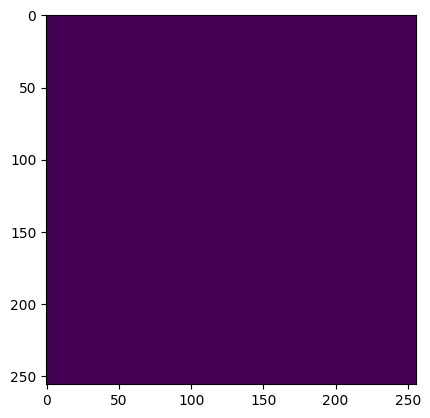

In [105]:
plt.imshow(arr)

In [36]:
dates = pd.date_range(start="2025-01-01",end="2025-01-10")

In [37]:
dates

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10'],
              dtype='datetime64[ns]', freq='D')

In [59]:
values = [28,np.nan,29,30,np.nan, np.nan,31,32,np.nan,np.nan]

In [60]:
len(values)

10

In [61]:
ts = pd.Series(values,index=dates)

In [62]:
ts

2025-01-01    28.0
2025-01-02     NaN
2025-01-03    29.0
2025-01-04    30.0
2025-01-05     NaN
2025-01-06     NaN
2025-01-07    31.0
2025-01-08    32.0
2025-01-09     NaN
2025-01-10     NaN
Freq: D, dtype: float64

In [63]:
## no of nones = n
## interpolate number = (forward_value-backward_value)/n+1
## Incase of there is no backward value then nones will as it is
## Incase of there is no forward_value- then backward will be replaced inplace of none.
## Linear Interpolation
## Quadratic, Polynomial 
ts = ts.ffill()

In [64]:
ts_data["MILES*"].isna().sum()

0

In [67]:
ts

2025-01-01    28.0
2025-01-02    28.0
2025-01-03    29.0
2025-01-04    30.0
2025-01-05    30.0
2025-01-06    30.0
2025-01-07    31.0
2025-01-08    32.0
2025-01-09    32.0
2025-01-10    32.0
Freq: D, dtype: float64

In [71]:
## Moving Averages.
ts.rolling(window=3).max()

2025-01-01     NaN
2025-01-02     NaN
2025-01-03    29.0
2025-01-04    30.0
2025-01-05    30.0
2025-01-06    30.0
2025-01-07    31.0
2025-01-08    32.0
2025-01-09    32.0
2025-01-10    32.0
Freq: D, dtype: float64

In [72]:
#Window Problems will decrease the time complexity.
#Extract 2 numbers which are consecutive equal in a list
#Sliding Window problems

In [76]:
ts

2025-01-01    28.0
2025-01-02    28.0
2025-01-03    29.0
2025-01-04    30.0
2025-01-05    30.0
2025-01-06    30.0
2025-01-07    31.0
2025-01-08    32.0
2025-01-09    32.0
2025-01-10    32.0
Freq: D, dtype: float64

In [79]:
previous_day = ts.shift(1) 

In [78]:
current_day = ts

In [80]:
previous_day

2025-01-01     NaN
2025-01-02    28.0
2025-01-03    28.0
2025-01-04    29.0
2025-01-05    30.0
2025-01-06    30.0
2025-01-07    30.0
2025-01-08    31.0
2025-01-09    32.0
2025-01-10    32.0
Freq: D, dtype: float64

In [81]:
two_day_ts = pd.DataFrame({"Current_Day":current_day,"Previou_Day":previous_day})

In [84]:
change = two_day_ts["Current_Day"]-two_day_ts["Previou_Day"]
two_day_ts["Change"] = change

In [89]:
percentage_change = round((two_day_ts["Change"]/two_day_ts["Previou_Day"])*100,2)

In [90]:
two_day_ts["pct"] = percentage_change

In [91]:
two_day_ts

,Current_Day,Previou_Day,Change,pct
2025-01-01,28.0,NaN,NaN,NaN
2025-01-02,28.0,28.0,0.0,0.00
2025-01-03,29.0,28.0,1.0,3.57
2025-01-04,30.0,29.0,1.0,3.45
2025-01-05,30.0,30.0,0.0,0.00
2025-01-06,30.0,30.0,0.0,0.00
2025-01-07,31.0,30.0,1.0,3.33
2025-01-08,32.0,31.0,1.0,3.23
2025-01-09,32.0,32.0,0.0,0.00
2025-01-10,32.0,32.0,0.0,0.00


In [94]:
round(ts.pct_change()*100,2)

2025-01-01     NaN
2025-01-02    0.00
2025-01-03    3.57
2025-01-04    3.45
2025-01-05    0.00
2025-01-06    0.00
2025-01-07    3.33
2025-01-08    3.23
2025-01-09    0.00
2025-01-10    0.00
Freq: D, dtype: float64

In [95]:
ts.pct_change() ## (ts/ts.shift(1))/ts.shift(1))

2025-01-01         NaN
2025-01-02    0.000000
2025-01-03    0.035714
2025-01-04    0.034483
2025-01-05    0.000000
2025-01-06    0.000000
2025-01-07    0.033333
2025-01-08    0.032258
2025-01-09    0.000000
2025-01-10    0.000000
Freq: D, dtype: float64

In [98]:
(ts-ts.shift(1))/ts.shift(1)

2025-01-01         NaN
2025-01-02    0.000000
2025-01-03    0.035714
2025-01-04    0.034483
2025-01-05    0.000000
2025-01-06    0.000000
2025-01-07    0.033333
2025-01-08    0.032258
2025-01-09    0.000000
2025-01-10    0.000000
Freq: D, dtype: float64

In [101]:
future_day = ts.shift(-1) # Benchmarking ML models.

In [102]:
two_day_1 = pd.DataFrame({"current_day":current_day,"future_day":future_day})

In [103]:
two_day_1

,current_day,future_day
2025-01-01,28.0,28.0
2025-01-02,28.0,29.0
2025-01-03,29.0,30.0
2025-01-04,30.0,30.0
2025-01-05,30.0,30.0
2025-01-06,30.0,31.0
2025-01-07,31.0,32.0
2025-01-08,32.0,32.0
2025-01-09,32.0,32.0
2025-01-10,32.0,NaN
